# Pra-Pemrosesan Data dan Analisis Eksploratif (EDA)
Dokumen ini menguraikan tahapan pra-pemrosesan data secara sistematis dan akademis. Proses diawali dengan ekstraksi data mentah (*raw data*), observasi struktur fitur, pembuktian masalah waktu tunggu (*response time delay*), pembersihan derau (*noise reduction*), hingga penemuan pola melalui pembelajaran mesin tanpa pengawasan (*unsupervised learning*).



In [40]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi Visualisasi Akademik (Monokrom / Grayscale)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#333333', '#666666', '#999999', '#cccccc', '#000000'])



## BAB I: Observasi dan Inspeksi Data Mentah
Langkah pertama dalam penelitian adalah memuat korpus data mentah utama yang diekstrak dari riwayat aplikasi WhatsApp. Kita akan melakukan inspeksi awal untuk memahami dimensi dan tipe data yang tersedia.



In [41]:
# Memuat dataset
df_raw = pd.read_csv('data/master_chat_wa.csv')

# Menampilkan 5 baris pertama untuk observasi visual awal
display(df_raw.head())



,Country,Phone Number,Formatted Name,Display Name,Message Time,Message Type,Message Body,Message Id
0,Indonesia,6285752887496,Anda,anugerahcomputer4,2026-04-27 12:10:50,chat,【IMAGE】,true_211622366855206@lid_AC2292D9378555369E125...
1,Indonesia,6285752887496,Anda,anugerahcomputer4,2026-04-27 12:10:55,chat,Anugerah komputer,true_211622366855206@lid_ACEC981E86F9304411889...
2,Indonesia,6281156701235,+62 811-5670-1235,NaN,2026-04-27 16:13:57,chat,Oke bg,false_211622366855206@lid_ACCC7B568284EA7BDECA...
3,Indonesia,6281156701235,+62 811-5670-1235,NaN,2026-04-29 10:17:27,chat,Bg berapa kemarin harganya ya,false_211622366855206@lid_AC0056ED0CC9DBDAF77A...
4,Indonesia,6285752887496,Anda,anugerahcomputer4,2026-04-29 10:18:06,chat,Nnti tnya y bg blom dtg bos nya,true_211622366855206@lid_AC4ECED0F39172D7E0788...


Berdasarkan observasi pada Tabel di atas, dataset ini memiliki beberapa kolom. Untuk memastikan tidak ada kecacatan data struktural (seperti nilai *Null*), kita akan memeriksa informasi metadatanya.



In [42]:
# Memeriksa struktur tipe data dan kelengkapan nilai
df_raw.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3502 entries, 0 to 3501
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country         3502 non-null   object
 1   Phone Number    3502 non-null   int64 
 2   Formatted Name  3502 non-null   object
 3   Display Name    3418 non-null   object
 4   Message Time    3502 non-null   object
 5   Message Type    3502 non-null   object
 6   Message Body    3447 non-null   object
 7   Message Id      3502 non-null   object
dtypes: int64(1), object(7)
memory usage: 219.0+ KB


## BAB II: Ekstraksi Fitur dan Pembuktian Hipotesis Waktu Respons
Kolom `Message Id` memuat informasi yang berpotensi membedakan antara pesan pelanggan dan balasan pengurus (*admin*). Selain itu, terdapat identitas unik di dalam kolom tersebut yang diduga merupakan ID sesi percakapan. Kita akan menguji hipotesis ini.



In [43]:
# Mengonversi kolom waktu menjadi tipe objek Datetime agar dapat dihitung secara matematis
df_raw['Message Time'] = pd.to_datetime(df_raw['Message Time'], errors='coerce')

# Menghapus baris anomali yang tidak memiliki stempel waktu
df_raw = df_raw.dropna(subset=['Message Time'])

# Ekstraksi Fitur 1: Mengidentifikasi Pengirim (Admin vs Pelanggan)
# Hipotesis: Prefix 'true_' menandakan pesan terkirim oleh sistem (Admin), sedangkan 'false_' dari luar (Pelanggan)
df_raw['is_admin'] = df_raw['Message Id'].astype(str).str.startswith('true_')

# Ekstraksi Fitur 2: Mendapatkan ID Sesi Percakapan (Chat ID)
# String dipotong berdasarkan karakter *underscore* ('_') untuk mengambil nilai tengah
df_raw['Chat_ID'] = df_raw['Message Id'].astype(str).apply(lambda x: x.split('_')[1] if len(x.split('_')) > 1 else 'unknown')

display(df_raw[['Message Time', 'is_admin', 'Chat_ID', 'Message Body']].head())



,Message Time,is_admin,Chat_ID,Message Body
0,2026-04-27 12:10:50,True,211622366855206@lid,【IMAGE】
1,2026-04-27 12:10:55,True,211622366855206@lid,Anugerah komputer
2,2026-04-27 16:13:57,False,211622366855206@lid,Oke bg
3,2026-04-29 10:17:27,False,211622366855206@lid,Bg berapa kemarin harganya ya
4,2026-04-29 10:18:06,True,211622366855206@lid,Nnti tnya y bg blom dtg bos nya


Dengan berhasil diekstraksinya `Chat_ID` dan identitas pengirim, tahapan selanjutnya adalah melakukan perhitungan matematis selisih waktu (Delta) antar pesan. Tujuannya adalah untuk membuktikan rumusan masalah yang tertulis di Bab 1, yakni: seberapa parah tingkat pengabaian (*ignored messages*) yang dialami pelanggan.



In [44]:
# Mengurutkan percakapan berdasarkan ruang obrolan (Chat_ID) dan waktu secara kronologis
df_raw = df_raw.sort_values(by=['Chat_ID', 'Message Time']).reset_index(drop=True)

response_times = []
unreplied = 0
total_inquiries = 0

# Iterasi logis untuk mensimulasikan penghitungan waktu tunggu
for chat_id, group in df_raw.groupby('Chat_ID'):
    group = group.sort_values('Message Time').reset_index(drop=True)
    waiting = False
    inq_time = None
    
    for _, row in group.iterrows():
        if not row['is_admin']:
            # Ditemukan pesan masuk dari pelanggan
            if not waiting:
                waiting = True
                inq_time = row['Message Time']
                total_inquiries += 1
        else:
            # Ditemukan pesan keluar dari admin (Tanggapan)
            if waiting:
                delay_minutes = (row['Message Time'] - inq_time).total_seconds() / 60.0
                response_times.append(delay_minutes)
                waiting = False
                
    # Apabila iterasi selesai namun status 'waiting' masih bernilai True, pesan tidak pernah dibalas
    if waiting:
        unreplied += 1

print(f"Total Sesi Percakapan Unik yang Diinisiasi Pelanggan: {total_inquiries}")
print(f"Jumlah Sesi Percakapan Diabaikan (Tidak Ada Balasan Admin): {unreplied}")
print(f"Rata-Rata Waktu Tunggu Pelanggan (Bagi yang Dibalas): {np.mean(response_times):.2f} Menit")



Total Sesi Percakapan Unik yang Diinisiasi Pelanggan: 1171
Jumlah Sesi Percakapan Diabaikan (Tidak Ada Balasan Admin): 198
Rata-Rata Waktu Tunggu Pelanggan (Bagi yang Dibalas): 631.79 Menit


## BAB III: Visualisasi Fakta Penundaan Balasan (Validasi Latar Belakang)
Data komputasi di atas akan diproyeksikan ke dalam sebuah diagram lingkaran (*Pie Chart*). Diagram ini berfungsi sebagai bukti faktual (Garis Dasar / *Baseline*) yang memperkuat justifikasi akademik mengapa sistem Kecerdasan Buatan (AI) pemroses bahasa alami mutlak diperlukan pada studi kasus ini.



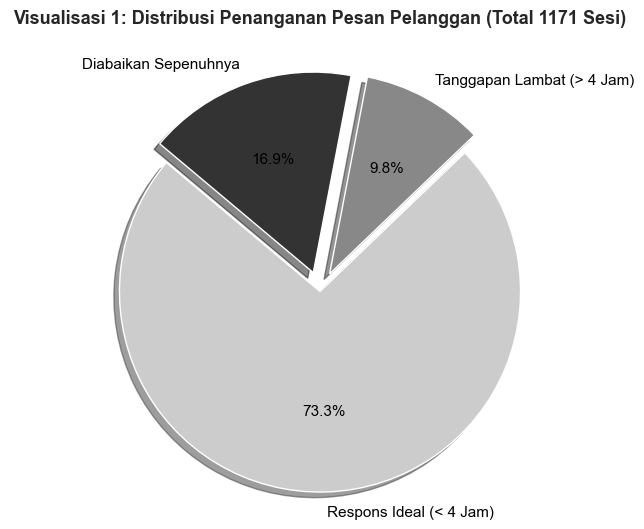

Kesimpulan Faktual:
Terdapat kegagalan responsivitas di mana 16.9% pesan diabaikan dan 9.8% ditanggapi dengan sangat lambat.


In [54]:
# Klasifikasi ambang batas keterlambatan ekstrem (> 4 Jam / 240 Menit)
lambat = sum(1 for x in response_times if x > 240)
normal = total_inquiries - unreplied - lambat

labels = ['Respons Ideal (< 4 Jam)', 'Tanggapan Lambat (> 4 Jam)', 'Diabaikan Sepenuhnya']
sizes = [normal, lambat, unreplied]
colors = ['#cccccc', '#888888', '#333333'] # Palet Monokromatik
explode = (0, 0.1, 0.1)

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', 
        shadow=True, startangle=140, textprops={'fontsize': 11, 'color': 'black'})
plt.title(f'Visualisasi 1: Distribusi Penanganan Pesan Pelanggan (Total {total_inquiries} Sesi)', fontsize=13, fontweight='bold', pad=20)
plt.axis('equal')
plt.show()

print("Kesimpulan Faktual:")
print(f"Terdapat kegagalan responsivitas di mana {unreplied/total_inquiries*100:.1f}% pesan diabaikan dan {(lambat/total_inquiries)*100:.1f}% ditanggapi dengan sangat lambat.")



## BAB IV: Pembersihan Derau (*Noise Reduction*) dan Pra-Pemrosesan Teks
Setelah membuktikan urgensi masalah, kita beralih ke persiapan korpus teks. Banyak percakapan memuat derau (*noise*) berupa karakter non-alfabetik atau teks otomatis (*broadcast*). Tahap ini bertujuan mendeduksi derau tersebut.



In [46]:
# Memisahkan pesan pelanggan saja (membuang pesan admin) untuk fokus pada analisis niat pelanggan
df_cust = df_raw[~df_raw['is_admin']].copy()

# Membuang pesan otomatis dari WhatsApp (misal mengandung karakter kurung siku tebal)
noise_pattern = r'【.*?】'
df_cust = df_cust[~df_cust['Message Body'].astype(str).str.contains(noise_pattern, regex=True)]
df_cust = df_cust.dropna(subset=['Message Body']).copy()
df_cust = df_cust[['Message Body']].rename(columns={'Message Body': 'text'})

def text_normalization(text):
    if not isinstance(text, str): return ""
    # Tahap 1: Case Folding (Konversi ke huruf kecil)
    text = text.lower()
    # Tahap 2: URL Removal (Menghilangkan tautan)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Tahap 3: Punctuation Removal (Menyisakan huruf alfabet saja)
    text = re.sub(r'[^a-z\s]', '', text)
    # Tahap 4: Whitespace Normalization
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Menerapkan fungsi normalisasi ke dalam kolom baru
df_cust['clean_text'] = df_cust['text'].apply(text_normalization)
df_cust = df_cust[df_cust['clean_text'] != '']

display(df_cust.head())



,text,clean_text
1,ly042213 bang,ly bang
3,"Baik bang, nanti sore diambilnya",baik bang nanti sore diambilnya
9,"Waalaikumsallam bg, kalau ganti hardisk apakah...",waalaikumsallam bg kalau ganti hardisk apakah ...
11,Okei bg saya tanya orng rumah dulu nnti saya k...,okei bg saya tanya orng rumah dulu nnti saya k...
13,Instal ulang dulu yak bg untuk sementara ini,instal ulang dulu yak bg untuk sementara ini


## BAB V: Penemuan Pola Tidak Terawasi (*Unsupervised Learning*)
Sebelum menetapkan *Ground Truth* secara manual, kita menggunakan pendekatan algoritma K-Means (*Clustering*) untuk menemukan struktur kelompok makna secara alami dari distribusi frekuensi dokumen (TF-IDF).



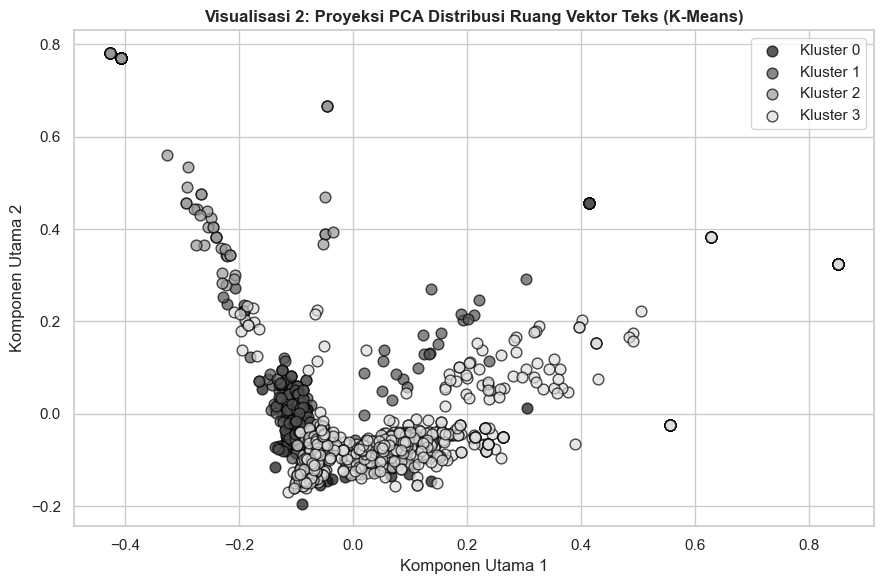

In [47]:
# Ekstraksi fitur menggunakan Term Frequency-Inverse Document Frequency (TF-IDF)
vectorizer = TfidfVectorizer(max_features=500, min_df=2)
X_tfidf = vectorizer.fit_transform(df_cust['clean_text'])

# Penugasan K-Means Clustering dengan k=4 kluster representatif
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X_tfidf)
df_cust['cluster'] = kmeans.labels_

# Mereduksi dimensi matriks menjadi 2D menggunakan Principal Component Analysis (PCA) untuk keperluan visualisasi
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())
df_pca = pd.DataFrame({'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1], 'Cluster': kmeans.labels_})

plt.figure(figsize=(9, 6))
# Penggunaan palet skala abu-abu (grayscale) untuk standardisasi akademik
colors_gray = ['#111111', '#555555', '#999999', '#dddddd']
for cluster_id in range(num_clusters):
    subset = df_pca[df_pca['Cluster'] == cluster_id]
    plt.scatter(subset['PCA1'], subset['PCA2'], c=colors_gray[cluster_id], label=f'Kluster {cluster_id}', edgecolor='black', alpha=0.7, s=60)

plt.title('Visualisasi 2: Proyeksi PCA Distribusi Ruang Vektor Teks (K-Means)', fontsize=12, fontweight='bold')
plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.legend()
plt.tight_layout()
plt.show()



## BAB VI: Pelabelan Heuristik (*Rule-Based Labeling*)
Berdasarkan wawasan yang diperoleh dari kluster di atas, mayoritas makna percakapan terpecah menjadi niat konfirmasi, penolakan, dan pertanyaan umum. Kita mengonversi wawasan ini menjadi fungsi pelabelan heuristik untuk membangun *Ground Truth*.



In [48]:
def heuristic_intent_labeler(text):
    keywords_setuju = ['lanjut', 'setuju', 'sikat', 'oke', 'boleh', 'iyak', 'ganti', 'kerjakan', 'aman', 'gas', 'baik', 'ok']
    keywords_batal = ['batal', 'cancel', 'ndak usah', 'kemahalan', 'mahal', 'ndak jadi', 'nanti dolok', 'urung', 'skip']    
    
    if any(word in text for word in keywords_batal):
        return 'batal'
    elif any(word in text for word in keywords_setuju):
        return 'setuju'
    else:
        return 'lainnya'

# Pengaplikasian pelabelan
df_cust['intent'] = df_cust['clean_text'].apply(heuristic_intent_labeler)

# Menghapus kolom sementara yang tidak dibutuhkan lagi
df_cust = df_cust.drop(columns=['cluster'])

display(df_cust['intent'].value_counts().to_frame(name="Frekuensi Label"))



,Frekuensi Label
intent,
lainnya,863
setuju,671
batal,34


## BAB VII: Integrasi Data Kuesioner (Transformasi Vertikal)
Data empiris (WhatsApp) sering kali kurang menonjolkan fitur linguistik dialek Melayu Pontianak yang diuji dalam penelitian ini. Oleh karena itu, kita mengekstraksi data hasil eksperimen kuesioner Google Forms (103 Responden). Data ini memiliki format tabuler horizontal yang harus ditransformasikan (*melt*) menjadi representasi vertikal.



In [49]:
file_kuesioner = 'data/Pengumpulan_Data_Linguistik_Interaksi_Layanan_Pelanggan_untuk_Pelatihan_Model_Natural_Language_Processing_(NLP)_(Jawaban).csv'
df_raw_kuesioner = pd.read_csv(file_kuesioner)

cols = df_raw_kuesioner.columns.tolist()
q1 = [c for c in cols if "1. Tuliskan balasan singkat secara natural" in c][0]
q2 = [c for c in cols if "2. Tuliskan balasan persetujuan dengan menggunakan dialek" in c][0]
q3 = [c for c in cols if "3. Tuliskan balasan singkat secara natural jika biaya ditolak" in c][0]
q4 = [c for c in cols if "4. Tuliskan balasan pembatalan perbaikan dengan menggunakan dialek" in c][0]
q5 = [c for c in cols if "5. Tuliskan balasan yang secara spesifik memuat negosiasi" in c][0]
q6 = [c for c in cols if "6. Tuliskan balasan yang mempertanyakan durasi" in c][0]

melted_rows = []
for _, row in df_raw_kuesioner.iterrows():
    if pd.notna(row[q1]): melted_rows.append({'text': row[q1], 'intent': 'setuju'})
    if pd.notna(row[q2]): melted_rows.append({'text': row[q2], 'intent': 'setuju'})
    if pd.notna(row[q3]): melted_rows.append({'text': row[q3], 'intent': 'batal'})
    if pd.notna(row[q4]): melted_rows.append({'text': row[q4], 'intent': 'batal'})
    if pd.notna(row[q5]): melted_rows.append({'text': row[q5], 'intent': 'lainnya'})
    if pd.notna(row[q6]): melted_rows.append({'text': row[q6], 'intent': 'lainnya'})

df_kuesioner = pd.DataFrame(melted_rows)
df_kuesioner['clean_text'] = df_kuesioner['text'].apply(text_normalization)

print(f"Peleburan sukses: Dari {len(df_raw_kuesioner)} Kolom Kuesioner menjadi {len(df_kuesioner)} Baris Data Vektoral.")
display(df_kuesioner.head(3))



Peleburan sukses: Dari 103 Kolom Kuesioner menjadi 618 Baris Data Vektoral.


,text,intent,clean_text
0,okeh,setuju,okeh
1,"Sikat jak bang, tpi saye nak nunggu disitok bi...",setuju,sikat jak bang tpi saye nak nunggu disitok bis...
2,Batal jak bang,batal,batal jak bang


## BAB VIII: Konsolidasi Multidimensi dan Keseimbangan Populasi (*Undersampling*)
Seluruh himpunan data (Korpus Utama, Korpus Suplemen, dan Korpus Kuesioner) akan disatukan ke dalam satu ruang himpunan gabungan. Mengingat klasifikasi rentan terhadap kelas mayoritas (*class imbalance*), teknik pemangkasan (*undersampling*) akan diterapkan secara acak agar ukuran populasi menjadi ekuilibrium sebelum diekspor ke tahap pelatihan mesin.



Volume Himpunan Gabungan: 2198 baris.


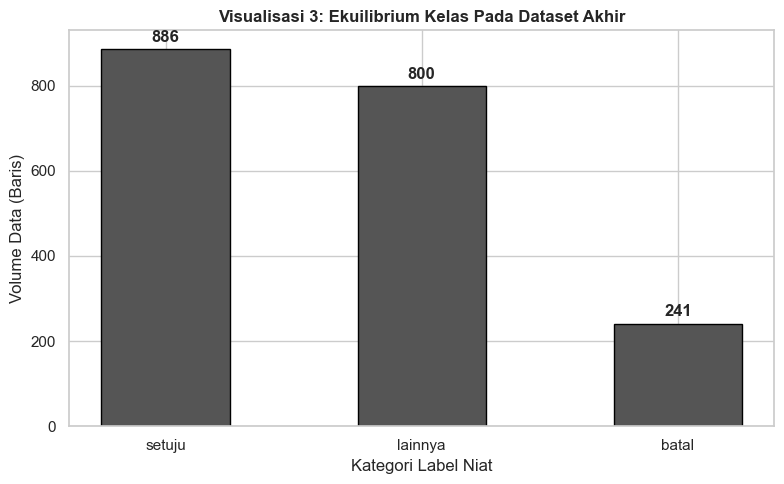

✅ EKSPOR BERHASIL: 1927 baris data bersih telah diekspor ke 'data/dataset_siap_latih_final.csv' dan siap masuk ke Modul Algoritma Pembelajaran (SVM).


In [50]:
# Memuat data suplemen
df_wa_suplemen = pd.read_csv('data/data_baru_dari_wa_clean.csv')
df_wa_suplemen['clean_text'] = df_wa_suplemen['text'].apply(text_normalization)
df_wa_suplemen['intent'] = df_wa_suplemen['intent'].astype(str).str.lower().str.strip()

# Penandaan Sumber Data
df_cust['source'] = 'master_wa'
df_kuesioner['source'] = 'kuesioner_dialek'
df_wa_suplemen['source'] = 'suplemen_manual'

# Konsolidasi Himpunan
df_combined = pd.concat([
    df_cust[['text', 'clean_text', 'intent', 'source']], 
    df_kuesioner[['text', 'clean_text', 'intent', 'source']], 
    df_wa_suplemen[['text', 'clean_text', 'intent', 'source']]
], ignore_index=True)

print(f"Volume Himpunan Gabungan: {len(df_combined)} baris.")

# Teknik Undersampling Acak menuju Batas Kuota Kesetaraan
TARGET_QUOTA = 800
df_lainnya = df_combined[df_combined['intent'] == 'lainnya'].copy()
df_setuju = df_combined[df_combined['intent'] == 'setuju'].copy()
df_batal = df_combined[df_combined['intent'] == 'batal'].copy()

if len(df_lainnya) > TARGET_QUOTA:
    df_lainnya = df_lainnya.sample(n=TARGET_QUOTA, random_state=42)
    
df_final = pd.concat([df_lainnya, df_setuju, df_batal], ignore_index=True)

# Visualisasi 3: Distribusi Populasi Final
plt.figure(figsize=(8, 5))
intent_counts = df_final['intent'].value_counts()
bars = plt.bar(intent_counts.index, intent_counts.values, color='#555555', edgecolor='black', width=0.5)

plt.title('Visualisasi 3: Ekuilibrium Kelas Pada Dataset Akhir', fontsize=12, fontweight='bold')
plt.xlabel('Kategori Label Niat')
plt.ylabel('Volume Data (Baris)')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(int(bar.get_height())),
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Ekspor
output_filename = 'data/dataset_siap_latih_final.csv'
df_final.to_csv(output_filename, index=False)
print(f"✅ EKSPOR BERHASIL: {len(df_final)} baris data bersih telah diekspor ke '{output_filename}' dan siap masuk ke Modul Algoritma Pembelajaran (SVM).")

